# **Cars Prediction** | 2025

# **I. Data Understanding**

## ***A. Penjabaran Studi Kasus***

Kami disini akan memprediksi apakah mobil ini berasal dari Amerika Serikat atau bukan AS. Tujuannya adalah untuk membantu tim pemasaran dan desain produk membuat keputusan strategis berdasarkan pola teknik mobil dari masing-masing wilayah.

Kami memprediksi dataset ini memakai model Naive Bayes.

Yang harus dilakukan :
1. Mapping
2. Coba pake cross-validation

## ***B. Import Libraries***

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tkinter as tk

## ***C. Import Dataset***

In [3]:
dataset = pd.read_csv('cars.csv')
dataset

,mpg,cylinders,cubicinches,hp,weightlbs,time-to-60,year,brand
0,14.0,8,350,165,4209,12,1972,US.
1,31.9,4,89,71,1925,14,1980,Europe.
2,17.0,8,302,140,3449,11,1971,US.
3,15.0,8,400,150,3761,10,1971,US.
4,30.5,4,98,63,2051,17,1978,US.
...,...,...,...,...,...,...,...,...
256,17.0,8,305,130,3840,15,1980,US.
257,36.1,4,91,60,1800,16,1979,Japan.
258,22.0,6,232,112,2835,15,1983,US.
259,18.0,6,232,100,3288,16,1972,US.


In [4]:
dataset[' brand'].unique()

<StringArray>
[' US.', ' Europe.', ' Japan.']
Length: 3, dtype: str

# **II. Data Preparation**

## ***A. Exploratory Data Analysis***

#### 1. Inspeksi Daftar Variabel

In [5]:
dataset.columns

Index(['mpg', ' cylinders', ' cubicinches', ' hp', ' weightlbs', ' time-to-60',
       ' year', ' brand'],
      dtype='str')

1. mpg = komsumsi bahan bakar (miles/gallon)
2. cylinders = jumlah silinder mesin
3. cubicinches = kapasitas mesin 
4. hp = tenaga kuda
5. weightlbs = berat mobil (pound)
6. time-to-60 = waktu akselerasi 0-60 mph (detik)
7. year = tahun produksi
8. brand = asal negara produsen (target)

In [6]:
dataset.columns = dataset.columns.str.strip()

#### 2. Inspeksi Informasi Ringkas

In [7]:
dataset['cubicinches'] = pd.to_numeric(dataset['cubicinches'], errors='coerce')
dataset['weightlbs'] = pd.to_numeric(dataset['weightlbs'], errors='coerce')

dataset['cubicinches'].fillna(dataset['cubicinches'].median(), inplace=True)
dataset['weightlbs'].fillna(dataset['weightlbs'].median(), inplace=True)

dataset['cubicinches'] = dataset['cubicinches'].astype(float)
dataset['weightlbs'] = dataset['weightlbs'].astype(float)

C:\Users\nizam\AppData\Local\Temp\ipykernel_8276\182537348.py:4: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  dataset['cubicinches'].fillna(dataset['cubicinches'].median(), inplace=True)
C:\Users\nizam\AppData\Local\Temp\ipykernel_8276\182537348.py:5: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series th

In [8]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 261 entries, 0 to 260
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   mpg          261 non-null    float64
 1   cylinders    261 non-null    int64  
 2   cubicinches  259 non-null    float64
 3   hp           261 non-null    int64  
 4   weightlbs    258 non-null    float64
 5   time-to-60   261 non-null    int64  
 6   year         261 non-null    int64  
 7   brand        261 non-null    str    
dtypes: float64(3), int64(4), str(1)
memory usage: 16.4 KB


In [9]:
fitur_kontinu = ['mpg', 'cubicinches', 'weightlbs']
fitur_diskrit = ['cylinders', 'hp', 'time-to-60', 'year']
all_fitur = ['mpg', 'cylinders', 'cubicinches', 'hp', 'weightlbs', 'time-to-60', 'year']

#### 3. Inspeksi Statistik Deskriptif

In [10]:
dataset.describe()

,mpg,cylinders,cubicinches,hp,weightlbs,time-to-60,year
count,261.000000,261.000000,259.000000,261.000000,258.000000,261.000000,261.000000
mean,23.144828,5.590038,200.918919,106.360153,3009.833333,15.547893,1976.819923
std,7.823570,1.733310,109.258305,40.499959,854.039019,2.910625,3.637696
min,10.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,1971.000000
25%,16.900000,4.000000,99.500000,75.000000,2248.000000,14.000000,1974.000000
50%,22.000000,6.000000,156.000000,95.000000,2867.500000,16.000000,1977.000000
75%,28.800000,8.000000,303.000000,138.000000,3670.000000,17.000000,1980.000000
max,46.600000,8.000000,455.000000,230.000000,4997.000000,25.000000,1983.000000


#### 4. Inspeksi Data NaN

In [11]:
dataset.isna().sum()

mpg            0
cylinders      0
cubicinches    2
hp             0
weightlbs      3
time-to-60     0
year           0
brand          0
dtype: int64

#### 5. Inspeksi Data Duplicated

In [12]:
dataset.duplicated().sum()

np.int64(0)

In [13]:
map_target = {" US." : 0, " Europe." : 1, " Japan." : 2}

dataset['brand'] = dataset['brand'].map(map_target)

#### 6. Univariate Analysis

##### *a. Inspeksi Distribusi Kelas Target*

In [14]:
target_count = dataset['brand'].value_counts()

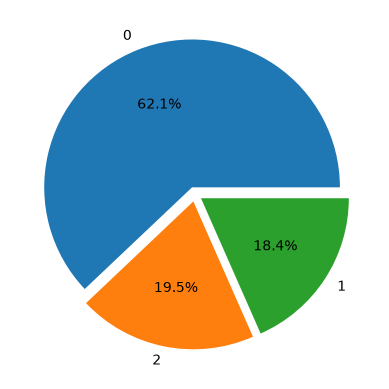

<Figure size 1000x1000 with 0 Axes>

In [15]:
explode = [0.05] * len(target_count)

plt.pie(
    target_count,
    labels=target_count.index,
    explode=explode,
    autopct="%1.1f%%"
)

plt.figure(figsize=(10,10))
plt.show()

##### *b. Inspeksi Distribusi Kelas Fitur*

In [16]:
def check_value(cols, top_n=5):
    for col in cols:
        print(f"Kolom: {col}")
        print(dataset[col].value_counts())
        print("\n")

check_value(all_fitur, top_n=5)

Kolom: mpg
mpg
14.0    16
18.0    14
13.0    13
16.0    12
15.0    10
        ..
19.4     1
44.3     1
32.1     1
36.4     1
23.5     1
Name: count, Length: 103, dtype: int64


Kolom: cylinders
cylinders
4    125
8     76
6     55
5      3
3      2
Name: count, dtype: int64


Kolom: cubicinches
cubicinches
97.0     16
98.0     13
250.0    13
318.0    13
350.0    12
         ..
76.0      1
383.0     1
130.0     1
110.0     1
454.0     1
Name: count, Length: 74, dtype: int64


Kolom: hp
hp
150    16
90     12
110    11
88     10
65      9
       ..
137     1
61      1
102     1
64      1
220     1
Name: count, Length: 85, dtype: int64


Kolom: weightlbs
weightlbs
2130.0    3
1795.0    2
1985.0    2
2720.0    2
2635.0    2
         ..
2372.0    1
3840.0    1
2835.0    1
3288.0    1
3353.0    1
Name: count, Length: 239, dtype: int64


Kolom: time-to-60
time-to-60
16    45
15    39
17    32
14    27
13    26
18    18
19    17
12    15
11    11
20     8
10     6
21     6
9      3
22     3
25

#### 7. Bivariate Analysis

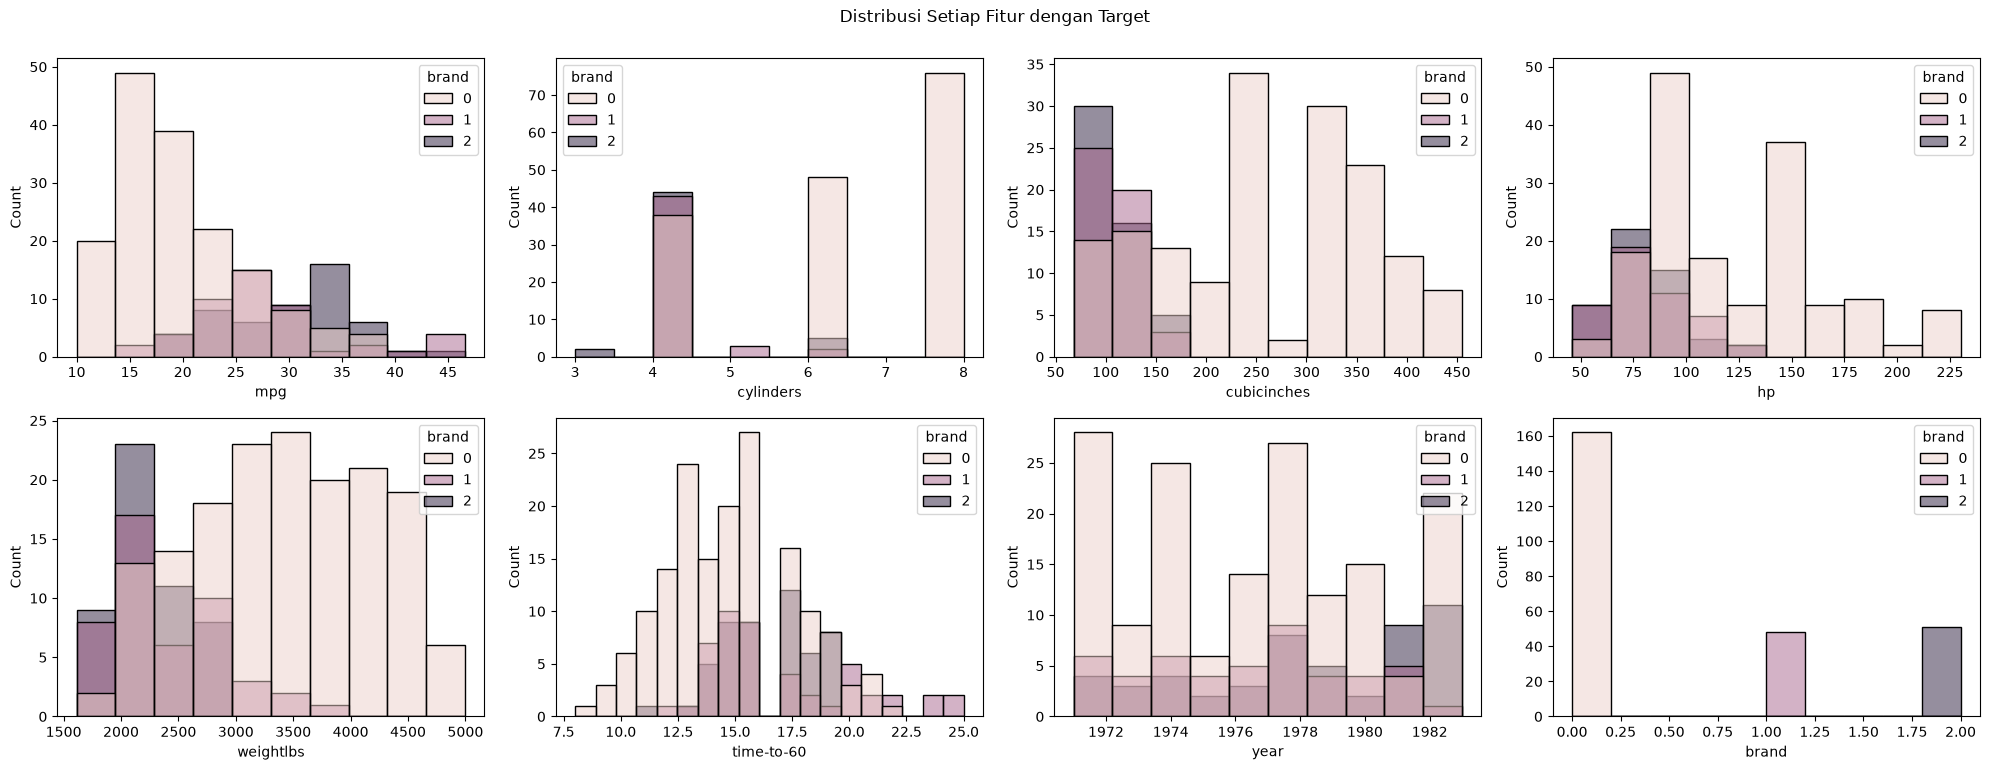

In [17]:
plt.figure(figsize=(20, 18))

for i, col in enumerate(dataset):
    plt.subplot(5, 4, i+1)
    sns.histplot(x=dataset[col], hue=dataset["brand"])

plt.suptitle("Distribusi Setiap Fitur dengan Target", y=1.001)
plt.tight_layout()
plt.show()

#### 8. Inspeksi Korelasi

##### *a. Mutual Information*

In [18]:
def probability_distribution(x):
    unique, counts = np.unique(x, return_counts=True)
    return counts / counts.sum()

def calculate_entropy(x):
    probs = probability_distribution(x)
    return -np.sum(probs * np.log2(probs + 1e-10))

def mutual_information(x, y):
    xy_pairs = list(zip(x, y))
    unique_xy, counts_xy = np.unique(xy_pairs, return_counts=True)
    probs_xy = counts_xy / counts_xy.sum()
    entropy_xy = -np.sum(probs_xy * np.log2(probs_xy + 1e-10))

    entropy_x = calculate_entropy(x)
    entropy_y = calculate_entropy(y)
    return entropy_x + entropy_y - entropy_xy

fitur = dataset[all_fitur]
target = dataset['brand']

mi_scores = {col: mutual_information(fitur[col].values, target.values) for col in fitur.columns}
mi_df = pd.DataFrame(list(mi_scores.items()), columns=["Feature", "Mutual Information"])
mi_df = mi_df.sort_values(by="Mutual Information", ascending=False)

C:\Users\nizam\AppData\Local\Temp\ipykernel_8276\3888338881.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=mi_df, x="Mutual Information", y="Feature", palette="viridis")
C:\Users\nizam\AppData\Local\Temp\ipykernel_8276\3888338881.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


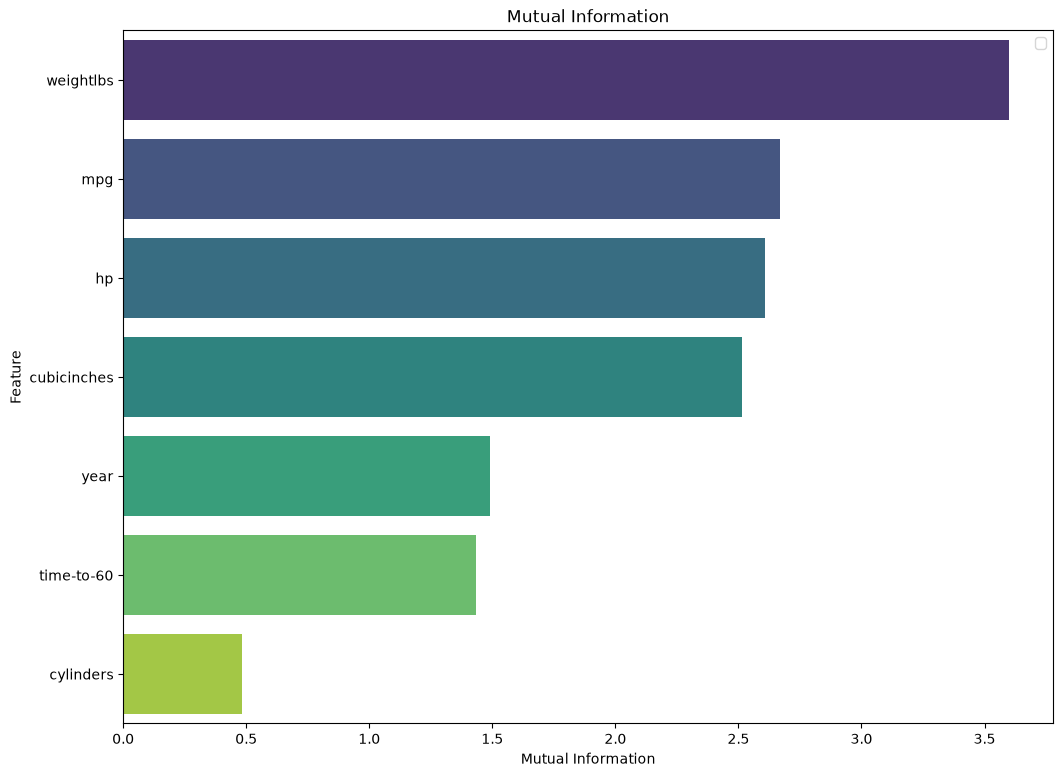

In [19]:
plt.figure(figsize=(12, 9))
sns.barplot(data=mi_df, x="Mutual Information", y="Feature", palette="viridis")
plt.xlabel("Mutual Information")
plt.ylabel("Feature")
plt.title("Mutual Information")
plt.legend()
plt.show()

In [20]:
mi_df

,Feature,Mutual Information
4,weightlbs,3.598907
0,mpg,2.669370
3,hp,2.607100
2,cubicinches,2.515027
6,year,1.492294
5,time-to-60,1.434004
1,cylinders,0.482460


##### *b. Kendall*


Kendall Correlation Matrix:
brand          1.000000
mpg            0.484582
time-to-60     0.249604
year           0.116273
hp            -0.425074
weightlbs     -0.512803
cubicinches   -0.578637
cylinders     -0.583370
Name: brand, dtype: float64


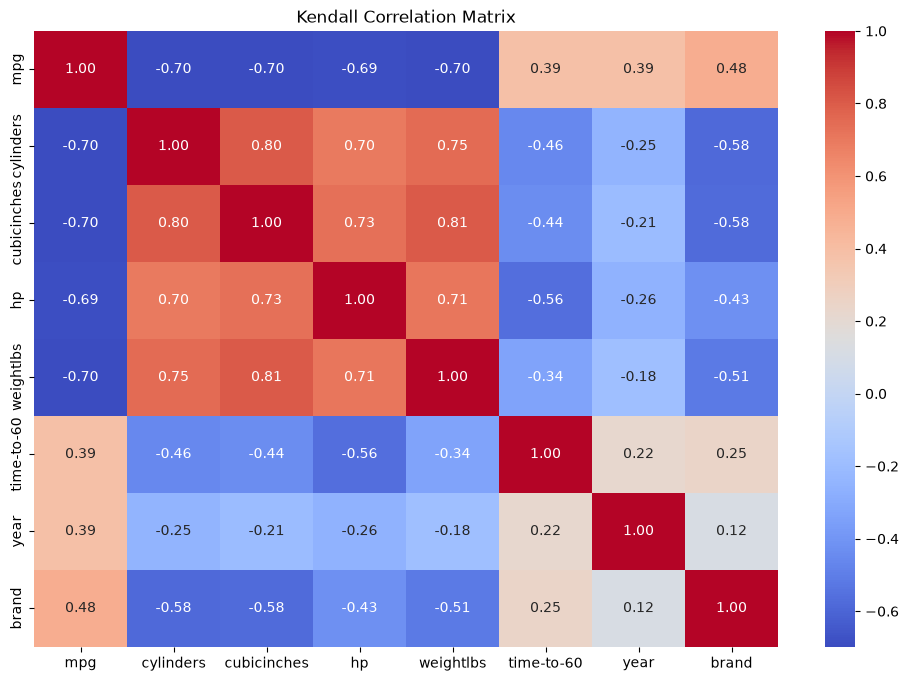

In [23]:
kendall_corr = dataset.corr(method="kendall")
print("\nKendall Correlation Matrix:")
print(kendall_corr["brand"].sort_values(ascending=False))

plt.figure(figsize=(12,8))
sns.heatmap(kendall_corr, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Kendall Correlation Matrix")
plt.show()

##### *c. Chi Square*

       Feature        Chi2  DOF
4    weightlbs  472.701090  476
2  cubicinches  370.093596  146
0          mpg  317.520093  204
3           hp  301.458522  168
1    cylinders  136.509979    8
5   time-to-60   82.908700   32
6         year   37.241309   24


C:\Users\nizam\AppData\Local\Temp\ipykernel_8276\2743440507.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Chi2", y="Feature", data=results_dataset.sort_values(by="Chi2", ascending=False), palette="magma")


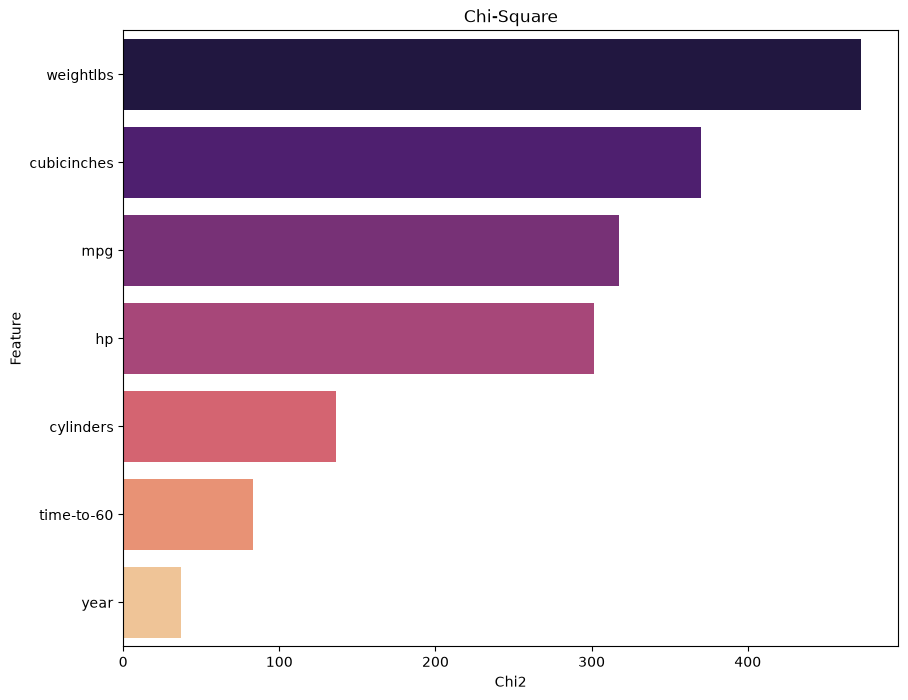

In [24]:
def chi_square_test(col, target):
    table = pd.crosstab(col, target)
    observed = table.values
    total = observed.sum()

    row_sum = observed.sum(axis=1).reshape(-1, 1)
    col_sum = observed.sum(axis=0).reshape(1, -1)
    expected = row_sum.dot(col_sum) / total

    chi2 = ((observed - expected)**2 / expected).sum()
    dof = (observed.shape[0] - 1) * (observed.shape[1] - 1)
    return chi2, dof

categorical_cols = dataset.drop("brand", axis=1).columns

results = []
for col in categorical_cols:
    chi2, dof = chi_square_test(dataset[col], dataset["brand"])
    results.append((col, chi2, dof))

results_dataset = pd.DataFrame(results, columns=["Feature", "Chi2", "DOF"])
print(results_dataset.sort_values(by="Chi2", ascending=False))

plt.figure(figsize=(10,8))
sns.barplot(x="Chi2", y="Feature", data=results_dataset.sort_values(by="Chi2", ascending=False), palette="magma")
plt.title("Chi-Square")
plt.ylabel("Feature")
plt.show()

#### 9. Inspeksi Outlier

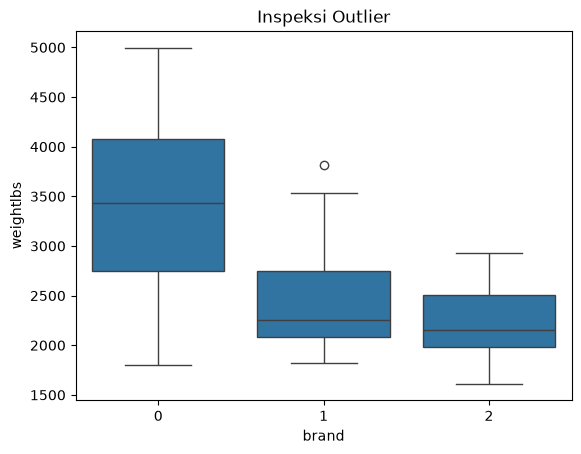

In [25]:
sns.boxplot(data=dataset, x="brand", y="weightlbs")
plt.title("Inspeksi Outlier")
plt.show()

## ***B. Feature Selection***

In [26]:
feature_cols = ['weightlbs', 'mpg', 'hp', 'cubicinches']

## ***C. Data Preparation***

In [27]:
target_column = 'brand'

## ***D. Splitting Dataset***

#### *a. Stratified Splitting Data*

In [28]:
def stratified_split(dataset, target_column, training_size=0.8, random_state=42):
    np.random.seed(random_state)
    train_list, test_list = [], []

    for class_value in dataset[target_column].unique():
        class_data = dataset[dataset[target_column] == class_value]
        class_data = class_data.sample(frac=1, random_state=random_state)

        split_idx = int(len(class_data) * training_size)
        train_list.append(class_data.iloc[:split_idx])
        test_list.append(class_data.iloc[split_idx:])

    train_set = pd.concat(train_list).reset_index(drop=True)
    test_set = pd.concat(test_list).reset_index(drop=True)
    return train_set, test_set

dataset_train, dataset_test = stratified_split(dataset, "brand")

#### *b. Stratified K-Fold*

In [29]:
def  stratified_kfold(dataset, target_column, n_split=5, random_state=42):
    np.random.seed(random_state)
    folds = [[] for _ in range(n_splits)]

    for class_value in dataset[target_column].unique():
        class_indices = dataset[dataset[target_column] == class_value].index.tolist()
        np.random.shuffle(class_indices)

        split_size = len(class_indices) // n_splits
        remainder = len(class_indices) % n_splits

        start_idx = 0
        for i in range(n_splits):
            end_idx = start_idx + split_size + (1 if i < remainder else 0)
            folds[i].extend(class_indices[start_idx:end_idx])
            start_idx = end_idx

        for fold_idx in range(n_splits):
            test_indices = folds[fold_idx]
            train_indices = []
            for other_fold in range(n_splits):
                if other_fold != fold_idx:
                    train_indices.extend(folds[other_fold])
            yield train_indices, test_indices

## ***E. Data Sampling***

In [30]:
def stratified_kfold(dataset, target_column, n_splits=5, random_state=42):
    np.random.seed(random_state)
    folds = [[] for _ in range(n_splits)]
    
    for class_value in dataset[target_column].unique():
        class_indices = dataset[dataset[target_column] == class_value].index.tolist()
        np.random.shuffle(class_indices)
        
        split_size = len(class_indices) // n_splits
        remainder = len(class_indices) % n_splits
        
        start_idx = 0
        for i in range(n_splits):
            end_idx = start_idx + split_size + (1 if i < remainder else 0)
            folds[i].extend(class_indices[start_idx:end_idx])
            start_idx = end_idx

    for fold_idx in range(n_splits):
        test_indices = folds[fold_idx]
        train_indices = []
        for other_fold in range(n_splits):
            if other_fold != fold_idx:
                train_indices.extend(folds[other_fold])
        yield train_indices, test_indices

target_column = 'brand'
feature_cols = ['weightlbs', 'mpg', 'hp', 'cubicinches']
n_splits = 5

def manual_oversample(X_train, y_train, target_column='brand', random_state=42):
    np.random.seed(random_state)
    train_df = X_train.copy()
    train_df[target_column] = y_train.values
    class_counts = train_df[target_column].value_counts()
    max_count = class_counts.max()
    
    balanced_dfs = []
    for class_label in class_counts.index:
        class_data = train_df[train_df[target_column] == class_label]
        if len(class_data) < max_count:
            sampled_data = class_data.sample(n=max_count, replace=True, random_state=random_state)
        else:
            sampled_data = class_data
        balanced_dfs.append(sampled_data)
    
    train_balanced = pd.concat(balanced_dfs).sample(frac=1, random_state=random_state).reset_index(drop=True)
    X_train_balanced = train_balanced.drop(target_column, axis=1)
    y_train_balanced = train_balanced[target_column]

    return X_train_balanced, y_train_balanced

folds_balanced = []

kfold_gen = stratified_kfold(dataset, target_column, n_splits=n_splits, random_state=42)

for fold_idx, (train_idx, test_idx) in enumerate(kfold_gen, 1):
    train_data = dataset.iloc[train_idx].reset_index(drop=True)
    test_data = dataset.iloc[test_idx].reset_index(drop=True)
    
    X_train = train_data[feature_cols].copy()
    y_train = train_data[target_column].copy()
    X_test = test_data[feature_cols].copy()
    y_test = test_data[target_column].copy()
    
    X_train_bal, y_train_bal = manual_oversample(X_train, y_train, target_column=target_column, random_state=42+fold_idx)
    
    folds_balanced.append({
        "fold": fold_idx,
        "X_train": X_train_bal,
        "y_train": y_train_bal,
        "X_test": X_test,
        "y_test": y_test
    })

## ***F. Feature Target Declaration***

In [31]:
feature_cols = dataset.drop('brand', axis=1).columns

dataset_training = pd.DataFrame(X_train, columns=feature_cols)
dataset_training['brand'] = y_train

dataset_testing = pd.DataFrame(X_test, columns=feature_cols)
dataset_testing['brand'] = y_test

In [32]:
feature_cols = [col for col in dataset_training.columns if col != "brand"]

X_train = dataset_training[feature_cols].to_numpy()
X_test = dataset_testing[feature_cols].to_numpy()

y_train = dataset_training["brand"].to_numpy()
y_test = dataset_testing["brand"].to_numpy()

## ***G. Model Application***

In [33]:
class ManualGaussianNB:
    def __init__(self):
        self.classes = None
        self.priors = {}
        self.mean = {}
        self.var = {}

    def fit(self, X, y):
        self.classes = np.unique(y)
        n_samples, n_features = X.shape

        for c in self.classes:
            X_c = X[y == c]
            self.priors[c] = len(X_c) / n_samples
            self.mean[c] = np.mean(X_c, axis=0)
            self.var[c] = np.var(X_c, axis=0) + 1e-9

    def _gaussian_pdf(self, x, mean, var):
        coeff = 1 / np.sqrt(2 * np.pi * var)
        exponent = np.exp(- (x - mean)**2 / (2 * var))
        return coeff * exponent

    def predict_proba(self, X):
        n_samples, n_features = X.shape
        probabilities = np.zeros((n_samples, len(self.classes)))

        for idx, c in enumerate(self.classes):
            prior = np.log(self.priors[c])  # log prior
            likelihood = np.sum(
                np.log(self._gaussian_pdf(X, self.mean[c], self.var[c])), 
                axis=1
            )
            probabilities[:, idx] = prior + likelihood

        exp_probs = np.exp(probabilities - np.max(probabilities, axis=1, keepdims=True))
        return exp_probs / np.sum(exp_probs, axis=1, keepdims=True)

    def predict(self, X):
        proba = self.predict_proba(X)
        return self.classes[np.argmax(proba, axis=1)]

In [34]:
fold_results = []

for fold_data in folds_balanced:
    fold_idx = fold_data["fold"]
    X_train_fold = fold_data["X_train"].to_numpy()
    y_train_fold = fold_data["y_train"].to_numpy()
    X_test_fold = fold_data["X_test"].to_numpy()
    y_test_fold = fold_data["y_test"].to_numpy()

    nb_model = ManualGaussianNB()
    nb_model.fit(X_train_fold, y_train_fold)

    y_pred_fold = nb_model.predict(X_test_fold)
    accuracy = np.mean(y_pred_fold == y_test_fold)
    fold_results.append({
        "fold": fold_idx,
        "accuracy": accuracy,
        "y_true": y_test_fold,
        "y_pred": y_pred_fold
    })

    print(f"Fold {fold_idx} Accuracy: {accuracy:.4f}")

mean_accuracy = np.mean([res["accuracy"] for res in fold_results])
print(f"\nRata-rata akurasi cross-validation: {mean_accuracy:.4f}")

Fold 1 Accuracy: 0.6111
Fold 2 Accuracy: 0.6226
Fold 3 Accuracy: 0.6154
Fold 4 Accuracy: 0.6275
Fold 5 Accuracy: 0.6275

Rata-rata akurasi cross-validation: 0.6208


## ***H. Visualisasi Model***

In [35]:
def plot_confusion_matrix(y_true, y_pred, classes, title="Confusion Matrix"):
    n_classes = len(classes)
    cm = np.zeros((n_classes, n_classes), dtype=int)

    for true, pred in zip(y_true, y_pred):
        cm[true, pred] += 1

    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return cm

all_y_true = np.concatenate([res["y_true"] for res in fold_results])
all_y_pred = np.concatenate([res["y_pred"] for res in fold_results])

## ***I. Evaluasi Model***

#### 1. Confusion Matrix

In [36]:
def classification_report_manual(y_true, y_pred, class_names):
    n_classes = len(class_names)
    report = {}

    for i, class_name in enumerate(class_names):
        tp = np.sum((y_true == i) & (y_pred == i))
        fp = np.sum((y_true != i) & (y_pred == i))
        fn = np.sum((y_true == i) & (y_pred != i))

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

        report[class_name] = {
            "precision": precision,
            "recall": recall,
            "f1-score": f1,
            "support": np.sum(y_true == i)
        }

    avg_precision = np.mean([report[c]["precision"] for c in class_names])
    avg_recall = np.mean([report[c]["recall"] for c in class_names])
    avg_f1 = np.mean([report[c]["f1-score"] for c in class_names])
    total_support = len(y_true)
    
    report["macro avg"] = {
        "precision": avg_precision,
        "recall": avg_recall,
        "f1-score": avg_f1,
        "support": total_support
    }
    
    print("\n" + "="*60)
    print("CLASSIFICATION REPORT (MANUAL)")
    print("="*60)
    print("{:<15} {:<10} {:<10} {:<10} {:<10}".format("Class", "Precision", "Recall", "F1-Score", "Support"))
    print("-"*60)
    for cls in class_names:
        p = report[cls]["precision"]
        r = report[cls]["recall"]
        f = report[cls]["f1-score"]
        s = report[cls]["support"]
        print("{:<15} {:<10.4f} {:<10.4f} {:<10.4f} {:<10}".format(cls, p, r, f, s))
    
    print("-"*60)
    p_avg = report["macro avg"]["precision"]
    r_avg = report["macro avg"]["recall"]
    f_avg = report["macro avg"]["f1-score"]
    s_total = report["macro avg"]["support"]
    print("{:<15} {:<10.4f} {:<10.4f} {:<10.4f} {:<10}".format("macro avg", p_avg, r_avg, f_avg, s_total))
    print("="*60)
    
    return report

classification_report_manual(all_y_true, all_y_pred, class_names=["US", "Europe", "Japan"])


CLASSIFICATION REPORT (MANUAL)
Class           Precision  Recall     F1-Score   Support   
------------------------------------------------------------
US              0.6207     1.0000     0.7660     162       
Europe          0.0000     0.0000     0.0000     48        
Japan           0.0000     0.0000     0.0000     51        
------------------------------------------------------------
macro avg       0.2069     0.3333     0.2553     261       


{'US': {'precision': np.float64(0.6206896551724138),
  'recall': np.float64(1.0),
  'f1-score': np.float64(0.7659574468085107),
  'support': np.int64(162)},
 'Europe': {'precision': 0,
  'recall': np.float64(0.0),
  'f1-score': 0,
  'support': np.int64(48)},
 'Japan': {'precision': 0,
  'recall': np.float64(0.0),
  'f1-score': 0,
  'support': np.int64(51)},
 'macro avg': {'precision': np.float64(0.20689655172413793),
  'recall': np.float64(0.3333333333333333),
  'f1-score': np.float64(0.25531914893617025),
  'support': 261}}

#### 2. Bias and Variance Model

In [37]:
accuracies = np.array([res["accuracy"] for res in fold_results])
bias_proxy = 1 - mean_accuracy
variance_proxy = np.var(accuracies)

print(f"\n{'='*50}")
print("ANALISIS BIAS & VARIANCE (PROXY UNTUK KLASIFIKASI)")
print('='*50)
print(f"Rata-rata Akurasi (Proxy Low Bias)   : {mean_accuracy:.4f}")
print(f"Bias (1 - Akurasi Rata-rata)        : {bias_proxy:.4f}")
print(f"Variansi Akurasi Antar Fold (Proxy Variance): {variance_proxy:.6f}")
print(f"Std Deviasi Akurasi                 : {np.std(accuracies):.4f}")
print('='*50)


ANALISIS BIAS & VARIANCE (PROXY UNTUK KLASIFIKASI)
Rata-rata Akurasi (Proxy Low Bias)   : 0.6208
Bias (1 - Akurasi Rata-rata)        : 0.3792
Variansi Akurasi Antar Fold (Proxy Variance): 0.000043
Std Deviasi Akurasi                 : 0.0066


#### 3. K-Fold Cross Validation

In [38]:
for fold_data in folds_balanced:
    fold_idx = fold_data["fold"]
    y_train_fold = fold_data["y_train"]
    y_test_fold = fold_data["y_test"]
    
    train_counts = pd.Series(y_train_fold).value_counts().sort_index()
    test_counts = pd.Series(y_test_fold).value_counts().sort_index()
    
    print(f"\n>>> FOLD {fold_idx}:")
    print(f"Train - US: {train_counts.get(0, 0)}, Europe: {train_counts.get(1, 0)}, Japan: {train_counts.get(2, 0)}")
    print(f"Test  - US: {test_counts.get(0, 0)}, Europe: {test_counts.get(1, 0)}, Japan: {test_counts.get(2, 0)}")


>>> FOLD 1:
Train - US: 129, Europe: 129, Japan: 129
Test  - US: 33, Europe: 10, Japan: 11

>>> FOLD 2:
Train - US: 129, Europe: 129, Japan: 129
Test  - US: 33, Europe: 10, Japan: 10

>>> FOLD 3:
Train - US: 130, Europe: 130, Japan: 130
Test  - US: 32, Europe: 10, Japan: 10

>>> FOLD 4:
Train - US: 130, Europe: 130, Japan: 130
Test  - US: 32, Europe: 9, Japan: 10

>>> FOLD 5:
Train - US: 130, Europe: 130, Japan: 130
Test  - US: 32, Europe: 9, Japan: 10
